In [66]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from scipy import stats
import lightgbm as lgb
import optuna
from sklearn.metrics import log_loss

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pandas as pd
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [4]:
train = pd.read_csv("train.csv")

train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [5]:
train.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

1. 결측치 없음
2. target feature가 object로 되어 있음
3. categorical feature 총 7개
  - binary 형태는 그대로 두고 ordinal과 nominal 형태는 변형 필요

In [7]:
# target feature를 binary 형으로 변형
train["Heart Disease"] = train["Heart Disease"].map({"Presence": 1, "Absence": 0})

In [8]:
# 확인
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


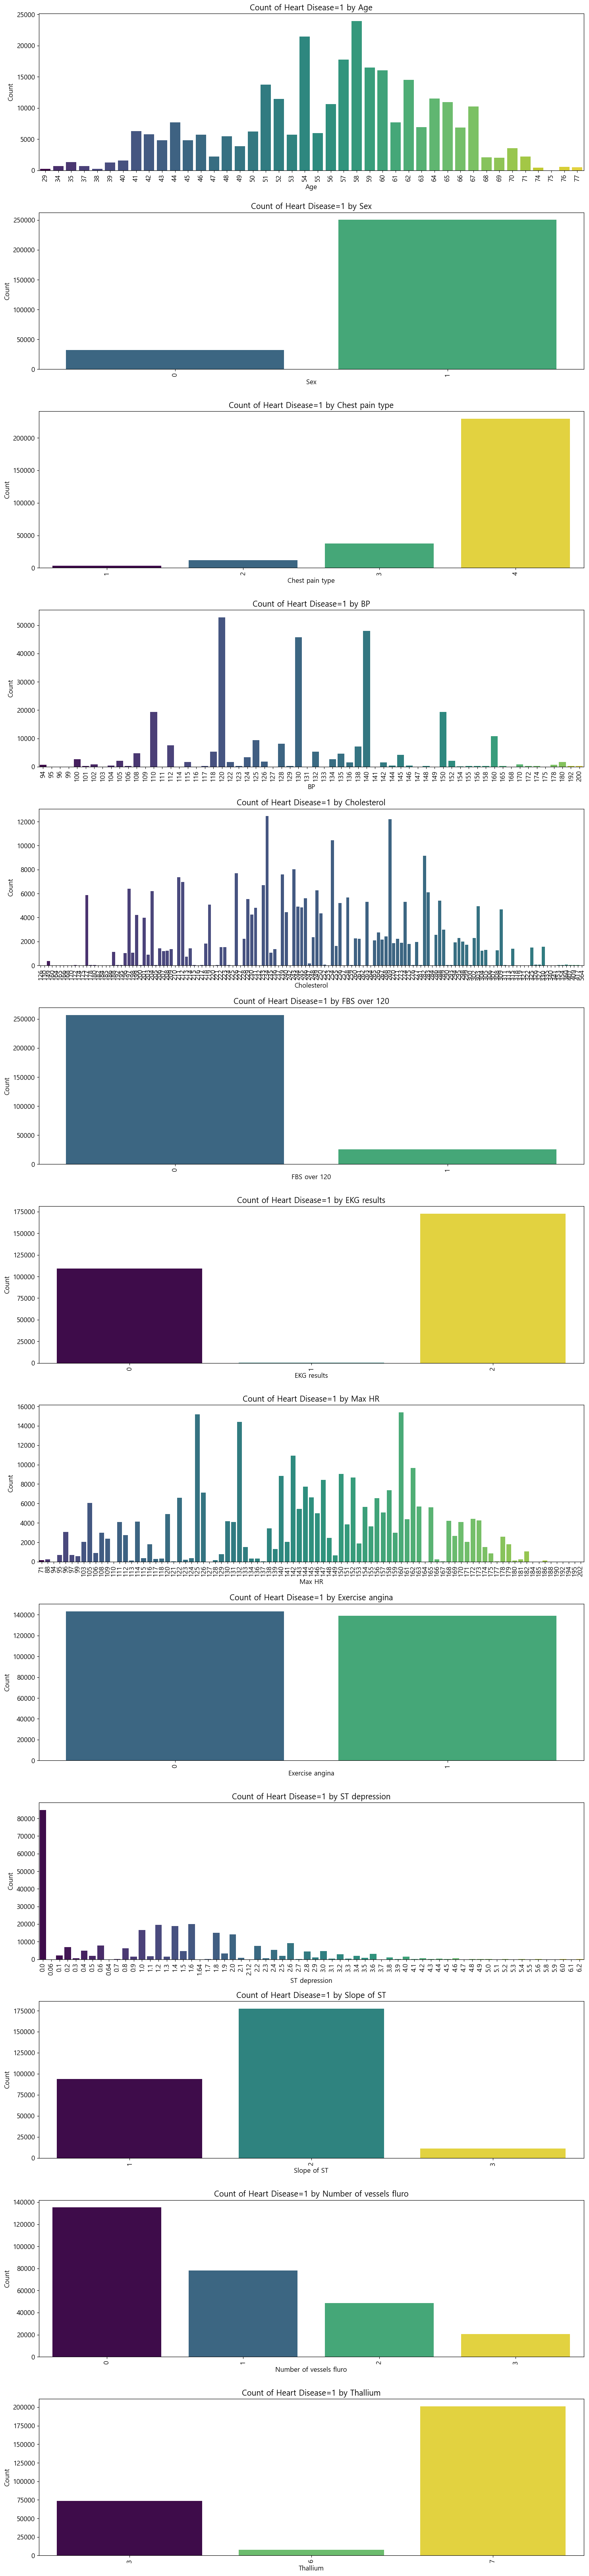

In [26]:
# target feature와의 관계 시각화

target_1_df = train[train['Heart Disease'] == 1]

# 2. 시각화할 컬럼 리스트 (ID와 Target 제외)
cols = train.drop(columns=['Heart Disease', 'id']).columns
n = len(cols)

plt.figure(figsize=(15, n * 5))
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 깨짐 방지

for i, col in enumerate(cols, 1):
    plt.subplot(n, 1, i)
    
    # x값을 hue에도 할당하고 legend를 끔으로써 경고를 해결합니다.
    sns.countplot(
        data=target_1_df, 
        x=col, 
        hue=col,            # x와 동일한 값을 hue에 전달
        palette='viridis', 
        legend=False        # 불필요한 범례 제거
    )
    
    plt.title(f'Count of Heart Disease=1 by {col}')
    plt.ylabel('Count')
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

1. Age: 41~67세 사이가 높음
2. Sex: 1(남성)의 경우가 훨씬 높음
3. Chest pain type: 4(증상 없음)의 경우가 다른 경우에 비해 압도적으로 높음
4. BP: 110, 120, 130, 140, 150, 160처럼 10의 배수인 경우가 압도적으로 높음
5. Cholesterol: 0에 가까운 값과 유난히 높은 값들이 있지만 특정 경향을 파악하기 어려움
6. FBS over 120: 0(공복 혈당 120mg/dL이 초과하지 않음)의 경우가 훨씬 높음
7. EKG results: 1(ST-T파 이상)은 거의 없음, 0(정상)은 100000 초과, 2(좌심실 비대)는 약 175000으로 많은 차이를 보임
8. Max HR: Cholesterol과 동일
9. Exercise angina: 0과 1의 차이가 거의 없음
10. ST depression: 0.0의 값이 압도적으로 높으며(80000이상) 0.1부터 4.6까지는 최대 20000 정도로 중앙이 높은 곡선 형태를 보임
11. Slope of ST: 2(평탄) 약 175000 -> 1(상승) 약 90000 -> 3(하강) 약 10000으로 심장 질환 위험도와 관계가 없이 보임
12. Number of vessles fluro: 숫자가 높아질 수록 값이 낮아지는 경향성을 띔
13. Thallium: 7(가역 결함) 약 200000 -> 3(정상) 약 75000 -> 6(고정 결함) 약 10000 으로 경향성이 보이지 않음


의문점
1. Age 컬럼에서 67세 이상부터는 왜 위험도가 떨어질까? 나이가 많을 수록 심장병 발병 위험도가 높다는 상식과 충돌
2. Chest pain type 컬럼과 Thallium 컬럼을 비교해 봤을 때, Chest pain type 컬럼의 1, 2번은 협심증의 흉통 유형을 가지고 있으며 낮은 수치를 기록하고 있는데 Thallium 컬럼에서 협심증이 진행 중임을 나타내는 7번은 왜 높을까?
3. BP는 휴식 시 혈압으로 특정 숫자에 구애받지 않을 거 같은데 왜 10의 배수마다 높을까?
4. Cholesterol과 Max HR은 정말 경향성이 없을까?
5. FBS over 120에서의 0은 정상 범위의 혈당인데 왜 발병 위험이 높을까?
6. ST depression의 그래프는 왜 그러한 모양을 띄고 있을까?
7. Slope of ST의 숫자가 높을 수록 심장 질환 위험도가 높아진다고 하는데 왜 3이 가장 낮은 수치를 기록하게 되었을까?


### 이번엔 Heart Disease 가 1인 경우 뿐만 아니라 0인 경우까지 같이 확인

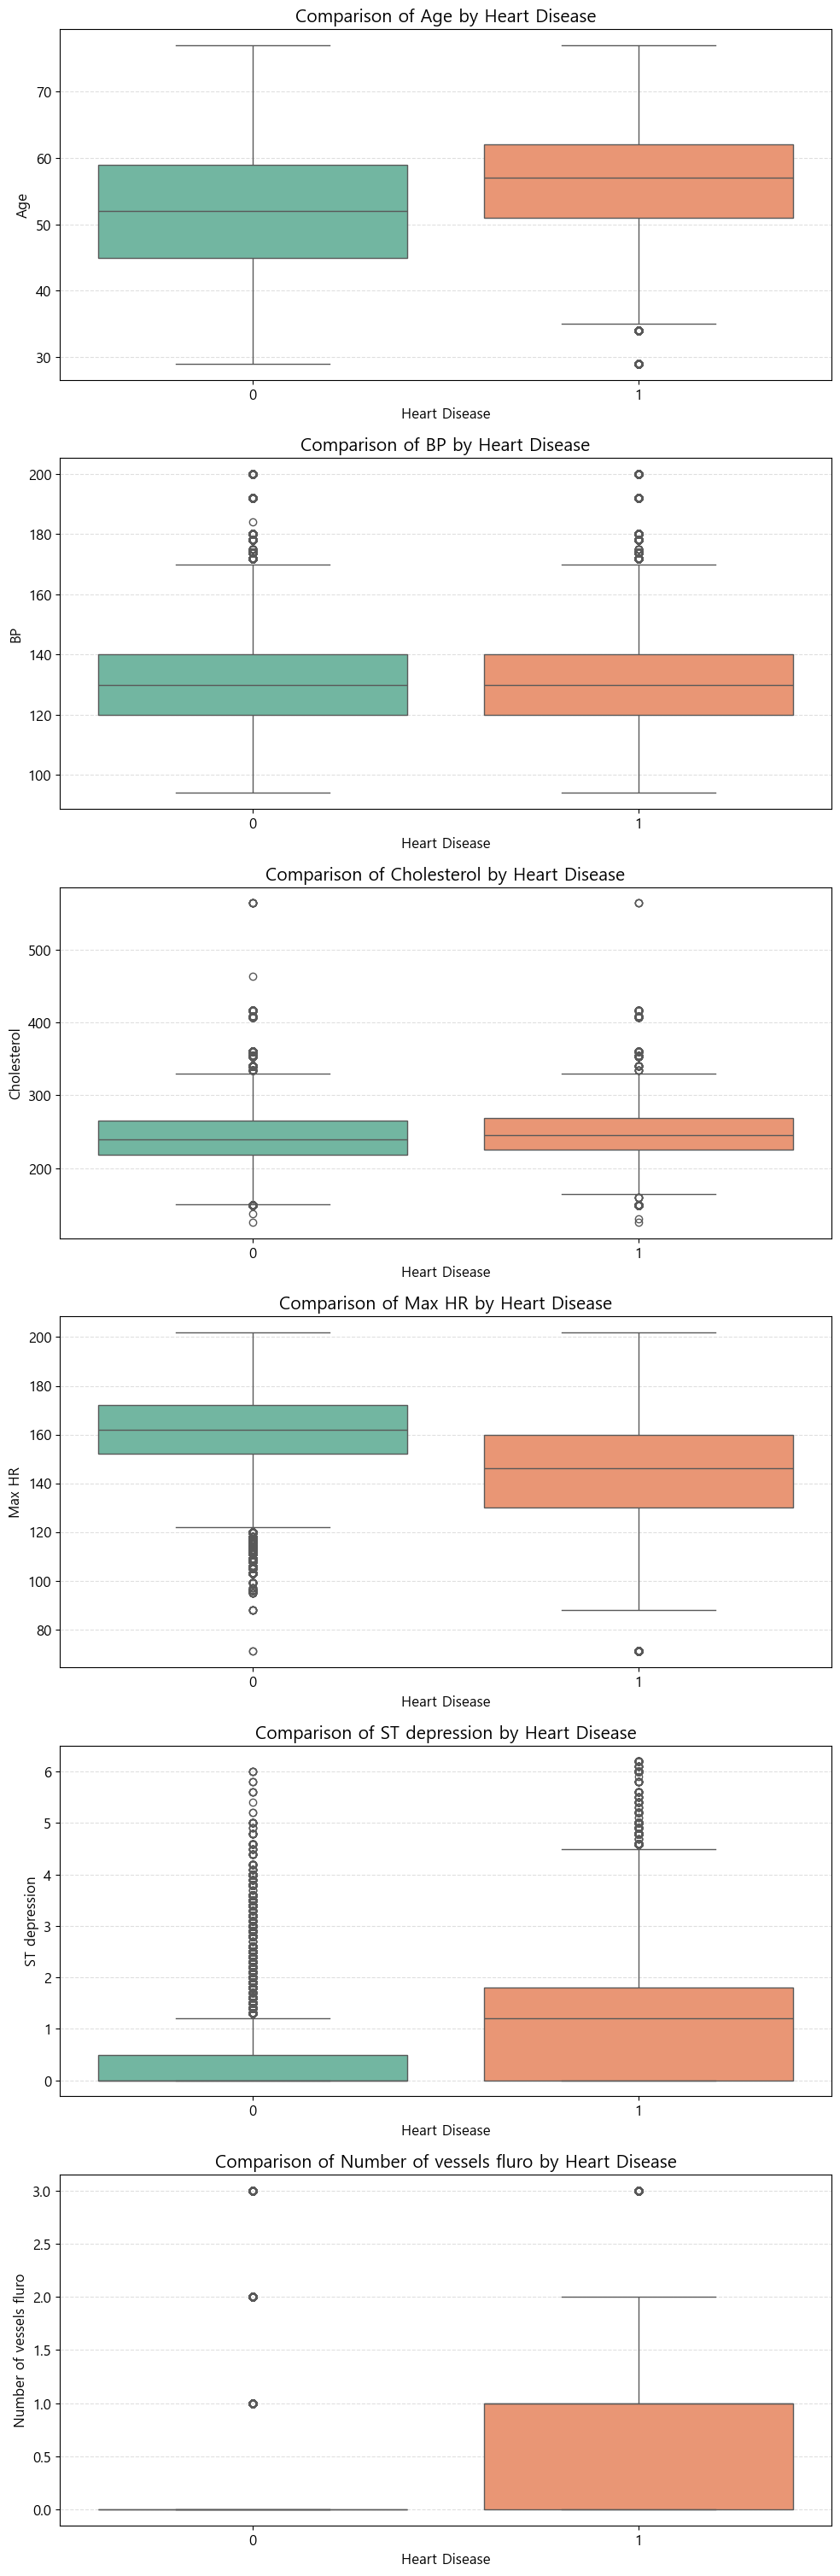

In [45]:
plt.figure(figsize=(10, n * 5))
plt.rcParams['font.family'] = 'Malgun Gothic'

check_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Number of vessels fluro']

for i, col in enumerate(check_cols, 1):
    plt.subplot(n, 1, i)
    
    # x축 값을 hue에도 할당하고 legend=False를 추가하여 경고를 해결합니다.
    sns.boxplot(
        data=train, 
        x='Heart Disease', 
        y=col, 
        hue='Heart Disease', # 무엇으로 색을 나눌지 명시
        palette='Set2', 
        legend=False         # 중복 범례 제거
    )
    
    plt.title(f'Comparison of {col} by Heart Disease', fontsize=15)
    plt.grid(axis='y', linestyle='--', alpha=0.4)


plt.tight_layout()
plt.show()

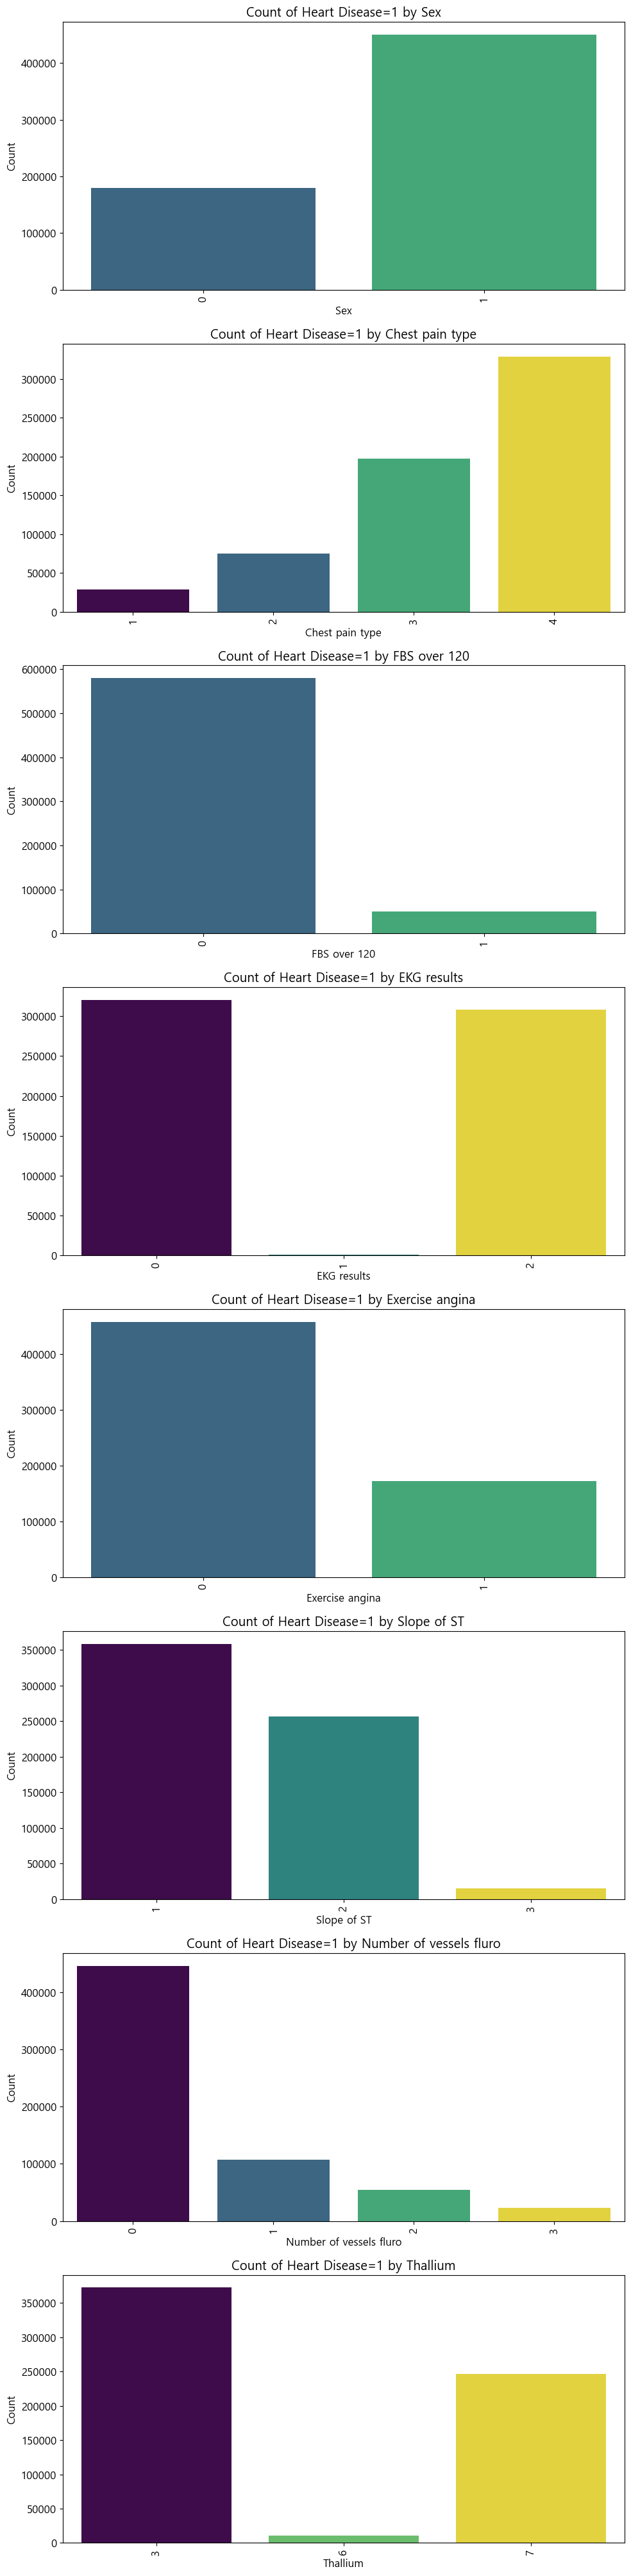

In [ ]:
bar_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Thallium']

plt.figure(figsize=(10, n * 5))

for i, col in enumerate(bar_cols, 1):
    plt.subplot(n, 1, i)
    
    # x값을 hue에도 할당하고 legend를 끔으로써 경고를 해결합니다.
    sns.countplot(
        data=train, 
        x=col, 
        hue=col,            # x와 동일한 값을 hue에 전달
        palette='viridis', 
        legend=False        # 불필요한 범례 제거
    )
    
    plt.title(f'Count of Heart Disease=1 by {col}')
    plt.ylabel('Count')
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

1. Age: 연령대가 높을 수록 심장병 발병 확률이 높다
2. Max HR: 낮을 수록
3. ST depression: 높을 수록
4. Sex: 남자일 수록
5. Chest pain type: 무증상일 수록(무증상 - 비협심증 - 비전형적 협심증 - 전형적 협심증 순서)
6. FBS over 120: 공복 혈당이 기준치(120 mg/dL) 초과하지 않는 사람일 수록
7. EKG results: ST-T파 이상인 경우에는 매우 낮음, 정상과 좌심실 비대 군은 비슷하게 높음
8. Exercise angina: 운동 유발 협심증이 유발되지 않는 사람들이 더 높음 -> Chest pain type 에서 확인한 결과와 연결 지을 수 있을 것으로 생각됨.(운동 유발 협심증이 있는 사람(=협심증 통증 증상이 있는 사람)은 정상인 사람 혹은 비협심증 통증이 있는 사람에 비해 발병 확률이 낮음)
9. Slope of ST: 분절의 기울기가 심할 수록(심장 질환 위험도가 낮을 수록) 발병 확률이 높음 -> 표본의 숫자 때문일 수 있으므로 박스 플롯 시각화 필요
10. Number of vessels fluro: 혈관 수가 적게 보일 수록 발병 확률이 높음 -> 9번과 동일한 이유로 흠...
11. Thallium: 현재 협심증이 진행 중인 7번이 가장 많았으며 정상인 3번 군이 고정 결함인 6번 군보다 높은 위험성을 보임

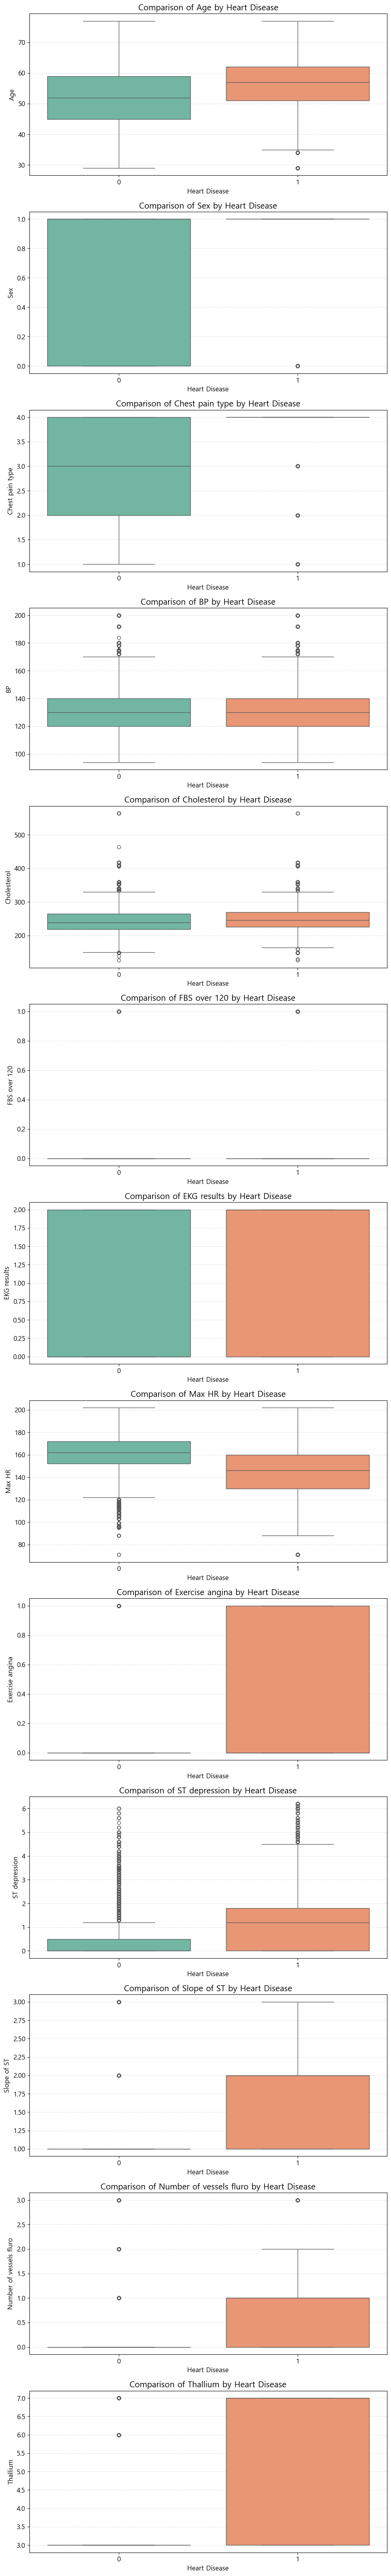

In [43]:
plt.figure(figsize=(10, n * 5))
plt.rcParams['font.family'] = 'Malgun Gothic'

check_cols = train.drop(columns = ['id', 'Heart Disease'])

for i, col in enumerate(check_cols, 1):
    plt.subplot(n, 1, i)
    
    # x축 값을 hue에도 할당하고 legend=False를 추가하여 경고를 해결합니다.
    sns.boxplot(
        data=train, 
        x='Heart Disease', 
        y=col, 
        hue='Heart Disease', # 무엇으로 색을 나눌지 명시
        palette='Set2', 
        legend=False         # 중복 범례 제거
    )
    
    plt.title(f'Comparison of {col} by Heart Disease', fontsize=15)
    plt.grid(axis='y', linestyle='--', alpha=0.4)


plt.tight_layout()
plt.show()

c:\Users\think\OneDrive\문서\projects\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\think\OneDrive\문서\projects\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


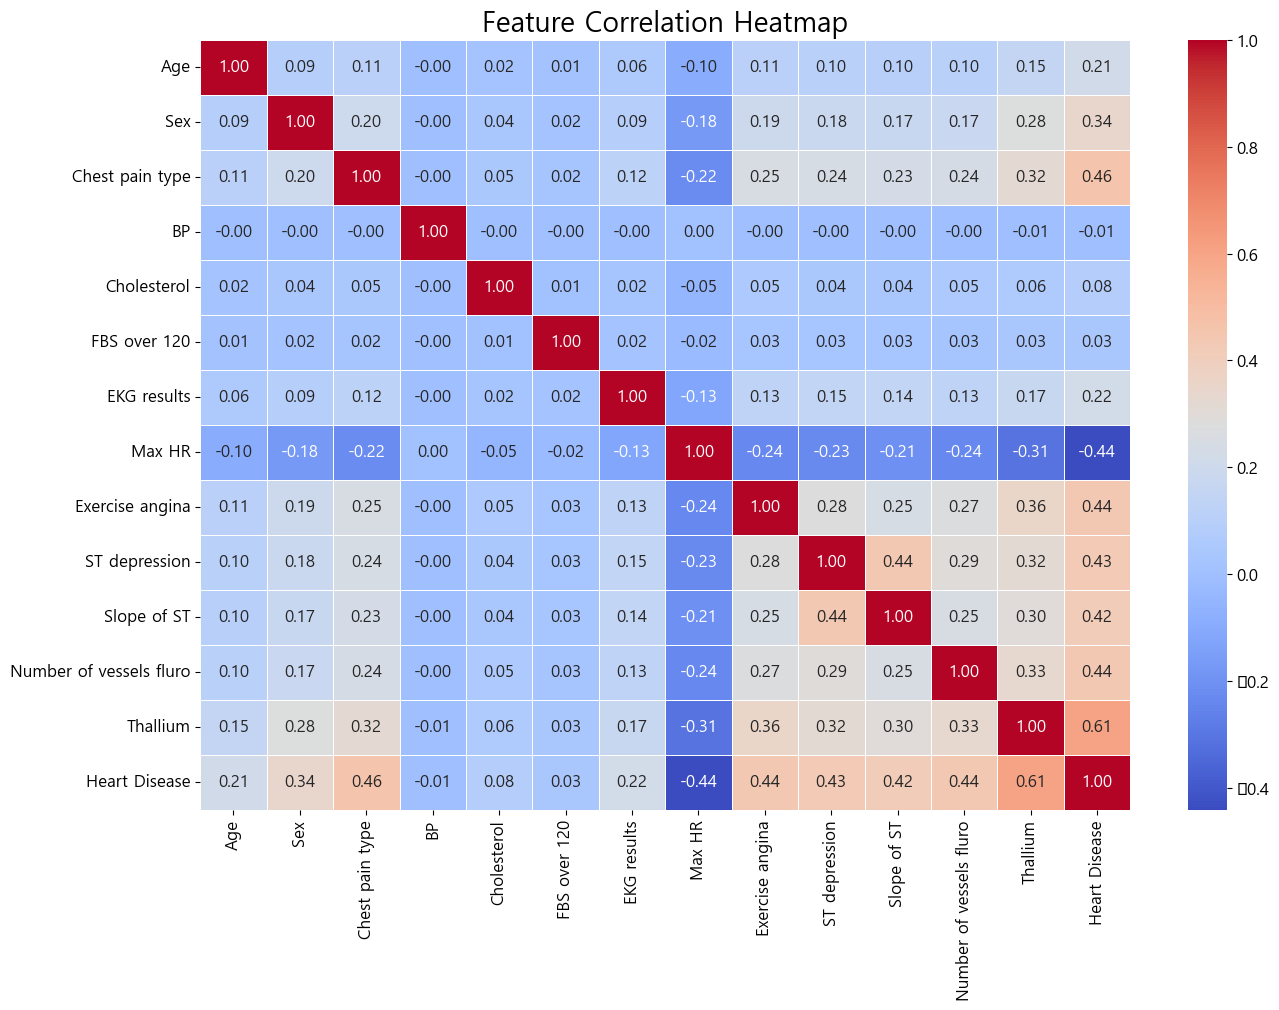

In [46]:
# 1. 상관관계 행렬 계산 (숫자형 데이터만 추출)
# id 컬럼은 의미가 없으므로 제외합니다.
corr_matrix = train.drop(columns=['id']).corr()

# 2. 히트맵 시각화
plt.figure(figsize=(15, 10))
plt.rcParams['font.family'] = 'Malgun Gothic'

# annot=True: 격자 안에 숫자 표시
# cmap='RdYlGn': 빨강(부정적/반비례), 노랑, 초록(긍정적/정비례) 색상 조합
# fmt=".2f": 소수점 둘째 자리까지 표시
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=20)
plt.show()

In [51]:
# 1. 원-핫 인코딩 (True/False 대신 0/1이 나오도록 dtype 지정)
oh_cols = ['Chest pain type', 'EKG results', 'Thallium']
train_prep = pd.get_dummies(train, columns=oh_cols, drop_first=False, dtype=int)

train_prep.head()

,id,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Slope of ST,...,Chest pain type_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_0,EKG results_1,EKG results_2,Thallium_3,Thallium_6,Thallium_7
0,0,58,1,152,239,0,158,1,3.6,2,...,0,0,0,1,1,0,0,0,0,1
1,1,52,1,125,325,0,171,0,0.0,1,...,1,0,0,0,0,0,1,1,0,0
2,2,56,0,160,188,0,151,0,0.0,1,...,0,1,0,0,0,0,1,1,0,0
3,3,44,0,134,229,0,150,0,1.0,2,...,0,0,1,0,0,0,1,1,0,0
4,4,58,1,140,234,0,125,1,3.8,2,...,0,0,0,1,0,0,1,1,0,0


In [52]:
# 1. 무증상 위험군 피처 추가 (가장 추천)
train_prep['silent_danger'] = ((train['Chest pain type'] == 4) & (train['Thallium'] == 7)).astype(int)

# 2. 고위험군 혈관 지표 (vessels가 있고 ST depression이 높은 경우)
train_prep['vessel_st_risk'] = (train['Number of vessels fluro'] * train['ST depression'])

# 3. 나이 비선형성 대응 (구간화)
train_prep['is_senior'] = (train['Age'] >= 60).astype(int)

# 새로운 피처를 추가한 후 다시 X, y를 분리하세요.
X = train_prep.drop(columns=['Heart Disease', 'id'])
y = train_prep['Heart Disease']

train_prep.head()

,id,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Slope of ST,...,Chest pain type_4,EKG results_0,EKG results_1,EKG results_2,Thallium_3,Thallium_6,Thallium_7,silent_danger,vessel_st_risk,is_senior
0,0,58,1,152,239,0,158,1,3.6,2,...,1,1,0,0,0,0,1,1,7.2,0
1,1,52,1,125,325,0,171,0,0.0,1,...,0,0,0,1,1,0,0,0,0.0,0
2,2,56,0,160,188,0,151,0,0.0,1,...,0,0,0,1,1,0,0,0,0.0,0
3,3,44,0,134,229,0,150,0,1.0,2,...,0,0,0,1,1,0,0,0,0.0,0
4,4,58,1,140,234,0,125,1,3.8,2,...,1,0,0,1,1,0,0,0,11.4,0


In [53]:
# 4. 학습용 / 검증용 데이터셋 분리 (8:2 비율)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. LightGBM 전용 데이터셋으로 변환
train_ds = lgb.Dataset(X_train, label=y_train)
valid_ds = lgb.Dataset(X_valid, label=y_valid, reference=train_ds)

In [60]:
# 1. Dataset 생성 시점에 파라미터를 미리 주입합니다.
# free_raw_data=False를 추가하면 메모리 에러를 방지하고 반복 학습에 유리합니다.
train_ds = lgb.Dataset(X_train, label=y_train, params={'feature_pre_filter': False})
valid_ds = lgb.Dataset(X_valid, label=y_valid, reference=train_ds, params={'feature_pre_filter': False})

def objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        
        # 여기에도 명시해주되, 위에서 Dataset을 이미 설정했으므로 충돌이 나지 않습니다.
        'feature_pre_filter': False, 
        
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }

    # early_stopping 콜백을 추가하여 효율을 높입니다.
    gbm = lgb.train(
        param, 
        train_ds, 
        valid_sets=[valid_ds],
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)] # 로그 간소화
    )
    
    preds = gbm.predict(X_valid)
    loss = log_loss(y_valid, preds)
    return loss

# 2. 다시 튜닝 시작
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

[I 2026-02-20 16:33:54,029] A new study created in memory with name: no-name-39ade6a3-4931-4cff-8380-2a6206aedb59


Training until validation scores don't improve for 50 rounds


[I 2026-02-20 16:33:57,046] Trial 0 finished with value: 0.2675600403362221 and parameters: {'lambda_l1': 9.50331942126871e-08, 'lambda_l2': 1.9680366056499916e-06, 'num_leaves': 40, 'feature_fraction': 0.71970153699516, 'bagging_fraction': 0.9863251440836368, 'bagging_freq': 6, 'min_child_samples': 75}. Best is trial 0 with value: 0.2675600403362221.


Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.26756
Training until validation scores don't improve for 50 rounds


[I 2026-02-20 16:33:59,670] Trial 1 finished with value: 0.26666062208975316 and parameters: {'lambda_l1': 0.06896623851625573, 'lambda_l2': 1.2241240562029797e-08, 'num_leaves': 70, 'feature_fraction': 0.4250479472848198, 'bagging_fraction': 0.7725000150023329, 'bagging_freq': 5, 'min_child_samples': 34}. Best is trial 1 with value: 0.26666062208975316.


...

[I 2026-02-20 16:44:25,087] Trial 97 finished with value: 0.26633447034936425 and parameters: {'lambda_l1': 0.000753636049225315, 'lambda_l2': 0.07532113307981304, 'num_leaves': 106, 'feature_fraction': 0.45060253557912, 'bagging_fraction': 0.9696182135498242, 'bagging_freq': 7, 'min_child_samples': 73}. Best is trial 87 with value: 0.2662418560036007.


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.26645


[I 2026-02-20 16:44:30,950] Trial 98 finished with value: 0.26644952353502904 and parameters: {'lambda_l1': 0.0007587418918699163, 'lambda_l2': 0.009744742505410287, 'num_leaves': 102, 'feature_fraction': 0.4527953175703654, 'bagging_fraction': 0.9774734370184304, 'bagging_freq': 7, 'min_child_samples': 73}. Best is trial 87 with value: 0.2662418560036007.


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.266489


[I 2026-02-20 16:44:36,877] Trial 99 finished with value: 0.26648895246101767 and parameters: {'lambda_l1': 6.825528555948246e-05, 'lambda_l2': 0.029139163114155694, 'num_leaves': 104, 'feature_fraction': 0.4834514901267502, 'bagging_fraction': 0.9683324249282532, 'bagging_freq': 7, 'min_child_samples': 76}. Best is trial 87 with value: 0.2662418560036007.


In [61]:
# 1. 최적의 파라미터 출력
print("Best Score: ", study.best_value)
print("Best Params: ", study.best_params)

# 2. 최종 파라미터 설정 (고정 파라미터 추가)
final_params = study.best_params
final_params['objective'] = 'binary'
final_params['metric'] = 'binary_logloss'
final_params['verbosity'] = -1
final_params['feature_pre_filter'] = False

# 3. 최종 모델 학습
final_model = lgb.train(
    final_params, 
    train_ds, 
    num_boost_round=1000, # 충분히 크게 설정
    valid_sets=[valid_ds],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

Best Score:  0.2662418560036007
Best Params:  {'lambda_l1': 0.001698673231263764, 'lambda_l2': 1.2817705218298092, 'num_leaves': 121, 'feature_fraction': 0.4374846863607808, 'bagging_fraction': 0.9648886506902979, 'bagging_freq': 5, 'min_child_samples': 87}
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[135]	valid_0's binary_logloss: 0.266008


In [62]:
from sklearn.metrics import classification_report, roc_auc_score

# 예측값 생성 (0~1 사이의 확률값)
y_pred_prob = final_model.predict(X_valid)
# 0.5를 기준으로 0과 1 분류
y_pred = [1 if x >= 0.5 else 0 for x in y_pred_prob]

# 성능 보고서 출력
print(classification_report(y_valid, y_pred))
print(f"AUC Score: {roc_auc_score(y_valid, y_pred_prob):.4f}")

              precision    recall  f1-score   support

           0       0.90      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

AUC Score: 0.9560


<Figure size 1000x800 with 0 Axes>

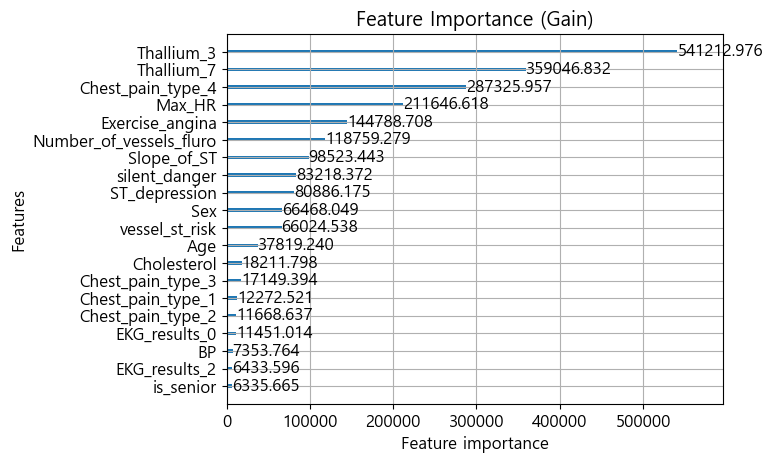

In [64]:
# 피처 중요도 시각화
plt.figure(figsize=(10, 8))
lgb.plot_importance(final_model, max_num_features=20, importance_type='gain')
plt.title('Feature Importance (Gain)')
plt.show()

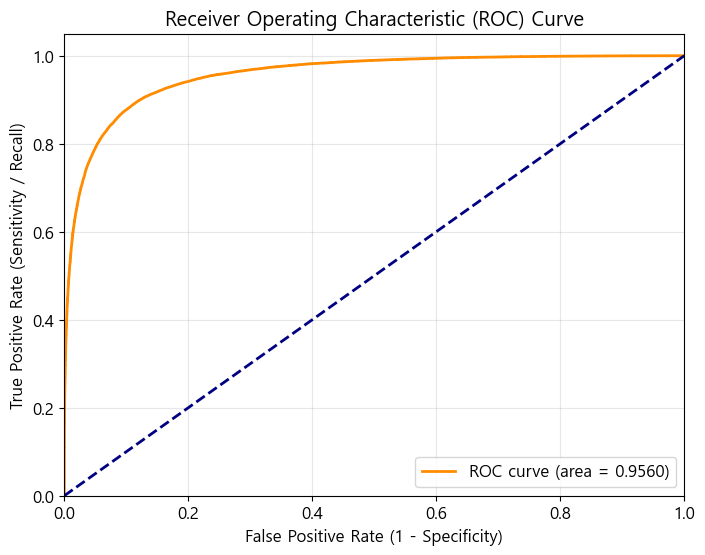

In [67]:
# 1. ROC 커브 데이터 계산
fpr, tpr, thresholds = roc_curve(y_valid, y_pred_prob)
roc_auc = auc(fpr, tpr)

# 2. 시각화
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 무작위 모델 기준선

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [68]:
# 1. 테스트 데이터 및 제출 양식 로드
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

# 2. 파생 변수 생성 (Train과 동일하게 적용)
test['silent_danger'] = ((test['Chest pain type'] == 4) & (test['Thallium'] == 7)).astype(int)
test['vessel_st_risk'] = (test['Number of vessels fluro'] * test['ST depression'])
test['is_senior'] = (test['Age'] >= 60).astype(int)

# 3. 범주형 데이터 원-핫 인코딩
oh_cols = ['Chest pain type', 'EKG results', 'Thallium']
test_prep = pd.get_dummies(test, columns=oh_cols, drop_first=False, dtype=int)

# 4. 수치형 변수 스케일링 (Train에서 학습시킨 scaler 재사용)
numeric_to_scale = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 
                    'Number of vessels fluro', 'Slope of ST']
test_prep[numeric_to_scale] = scaler.transform(test_prep[numeric_to_scale])

# 5. 피처 순서 맞추기 (학습 시 사용된 X_train.columns와 동일하게 정렬)
X_test = test_prep[X_train.columns]

# 6. 모델 예측 (확률값 생성)
test_preds = final_model.predict(X_test)

# 7. Sample Submission 양식에 결과 덮어쓰기
# 양식에 'id'가 이미 있으므로, 'Heart Disease' 컬럼만 예측값으로 채웁니다.
sample_submission['Heart Disease'] = test_preds

# 만약 결과가 확률값이 아니라 0 또는 1이어야 한다면 아래 주석을 해제하세요.
# sample_submission['Heart Disease'] = [1 if x >= 0.5 else 0 for x in test_preds]

# 8. 최종 CSV 저장
sample_submission.to_csv('final_submission.csv', index=False)
print("제출용 'final_submission.csv' 파일이 양식에 맞춰 생성되었습니다!")

제출용 'final_submission.csv' 파일이 양식에 맞춰 생성되었습니다!
